# <span style="color:rgb(213,80,0)">Simulation Output Structure</span>

We load some simulation input data and run the simulation. We obtain an `output` structure in return.


In [1]:
jsonstruct = parseBattmoJson('Examples/Documentation/jsonfiles/explore_output_example.json');
output = runBattery(jsonstruct);


## Output structure overview

The output structure contains the results of the simulation, the simulation model and the simulation setup. We have in particular the following

- `output.model` : The simulation model
- `output.simsetup` : The simulation setup
- `output.jsonstruct` : The json input file
- `output.time` : Time structure of the results
- `output.E` : Voltage for each time step
- `output.I` : Current for each time step
- `output.states` : The states structure with the internal state of the battery for each time step

## Current and Voltage

The readily available results are the current and voltage with the corresponding time structure



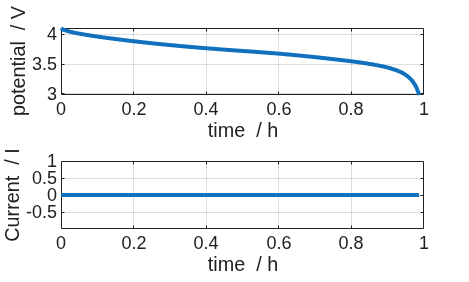

In [2]:
time = output.time;
E    = output.E;
I    = output.I;


figure
subplot(2,1,1)
plot(time/hour, E);
grid on
xlabel 'time  / h';
ylabel 'potential  / V';


subplot(2,1,2)
plot(time/hour, I);
grid on
xlabel 'time  / h';
ylabel 'Current  / I';


## Simulation Model

The simulation model is an output of the simulation.


In [3]:
model = output.model;


We can use it to plot the battery model, using the dedicated function `plotBatteryGrid`.



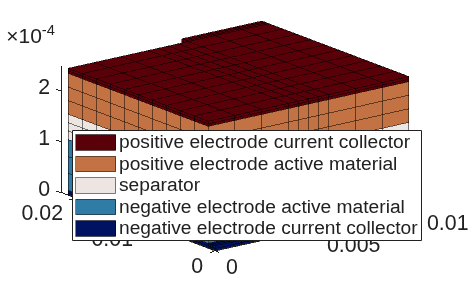

In [4]:
plotBatteryGrid(model);


## Battery States

The `states` give us insight into the internal state of the battery for each time step.


In [5]:
states = output.states;


The states are stored in a cell array. The index is the same as the time output. For a given state, the data is stored following the same architecture as the overall battery model, see [here](https://battmo.org/BattMo/architecture.html)

Let us consider the state computed at the last time step.


In [6]:
state = states{end}

state = struct with fields:
    NegativeElectrode: [1x1 struct]
    PositiveElectrode: [1x1 struct]
          Electrolyte: [1x1 struct]
         ThermalModel: [1x1 struct]
              Control: [1x1 struct]
                 time: 3.5517e+03


We obtain the following variable, which are (except time and control type) the *state* or *primary* variables. They correspond to the unknowns in the modeling equations we solve. It is possible to recover also the intermediate variables as illustrated below.

- `state.NegativeElectrode.Coating.ActiveMaterial.SolidDiffusion.cSurface`
- `state.NegativeElectrode.Coating.ActiveMaterial.SolidDiffusion.c`
- `state.NegativeElectrode.Coating.phi`
- `state.NegativeElectrode.CurrentCollector.phi`
- `state.PositiveElectrode.Coating.ActiveMaterial.SolidDiffusion.cSurface`
- `state.PositiveElectrode.Coating.ActiveMaterial.SolidDiffusion.c`
- `state.PositiveElectrode.Coating.phi`
- `state.PositiveElectrode.CurrentCollector.scaledDeltaPhi`
- `state.Electrolyte.phi`
- `state.Electrolyte.c`
- `state.ThermalModel.T`
- `state.Control.E`
- `state.Control.I`
- `state.Control.ctrlType`
- `state.time`

Let us plot the concentration in the electrolyte. The units are always defaulted to SI units. Note also the difference of scale for the different spatial directions.



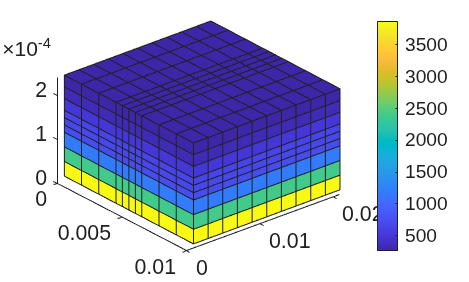

In [7]:
figure
plotCellData(model.Electrolyte.grid, state.Electrolyte.c);
colorbar
view([50, 40]);


## Simulation Setup

The simulation setup contains all the information to re\-run a simulation. It means the model, of course, but also the initial state, the schedule (time stepping choices) and the solver parameters.


In [8]:
simsetup = output.simsetup();
states = simsetup.run();


## Json Input

The `jsonstruct` that is returned in the output is the same as the one we sent as input but it is augmented with all the **default values**

## full set of state variables

In the simulation, intermediate variables are computed to assemble the equations. They can be relevant to explore your solution. They are not included by default because they require extra time to be computed. If you are interested in those, you can add the following entry in your json input structure


In [9]:
jsonstruct.Output.includeIntermediateVariables = true;
output = runBattery(jsonstruct);


It is also possible to do the same *manually* after the simulation


In [10]:
for istate = 1 : numel(states)
    states{istate} = model.addVariables(states{istate});
end


For example, for the negative electrode interface, we get the following variables, among which the OCP and the intercalation flux, which is the reaction rate of Lithium intercalation (mol/m^2/s).


In [11]:
state = states{end};
disp(state.NegativeElectrode.Coating.ActiveMaterial.Interface)

         phiElectrode: [300x1 double]
    cElectrodeSurface: [300x1 double]
       phiElectrolyte: [300x1 double]
         cElectrolyte: [300x1 double]
                 OCP0: [300x1 double]
                    T: [300x1 double]
                  OCP: [300x1 double]
                  eta: [300x1 double]
                   j0: [300x1 double]
    intercalationFlux: [300x1 double]